# Zero-noise extrapolation with custom extrapolation
Zero-noise extrapolation (ZNE) is a technique for mitigating errors in estimating expectation values of observables. While it often improves results, it is not guaranteed to produce an unbiased result.

ZNE consists of two stages:

* Noise amplification: The original quantum circuit is executed multiple times at different noise rates.
* Extrapolation: The ideal result is estimated by extrapolating the noisy expectation value results to the zero-noise limit.

Both the noise amplification and extrapolation stages can be implemented in many different ways. ``qiskit-mitigation`` has implementations for two amplification methods -
* Noise amplification by "digital gate folding", which means that two-qubit gates are replaced with equivalent sequences of the gate and its inverse. For example, replacing a unitary $U$ with $U U^† U$ would yield a noise amplification factor of 3.
* Noise amplification by Probabilistic Error Amplification (PEA), as suggested in ["Evidence for the utility of quantum computing before fault tolerance"](https://www.nature.com/articles/s41586-023-06096-3). The noise of each layer of two-qubit gates is first learned. Using the learned noise, the noise can be amplified by probabilistically injecting noise proportional to the corresponding learned noise model, with a wanted noise factor.

For the extrapolation, ``qiskit-mitigation`` contains several functional forms, including a linear fit, an exponential fit or a double exponential fit. One can also use a custom extrapolation function.

In this guide we will show how to use GateFolding and PEA classes in ``qiskit-mitigation`` to mitigate gate errors. We will also demonstrate how to use your own custom fitting method for extrapolation.
The guide uses a simulator, so no IBM Quantum® credentials are needed.

## Setup

In [1]:
import warnings
from collections.abc import Sequence

import matplotlib.pyplot as plt
import numpy as np
from qiskit.circuit import Parameter, QuantumCircuit
from qiskit.providers.fake_provider import GenericBackendV2
from qiskit.quantum_info import PauliLindbladMap, SparsePauliOp, pauli_basis
from qiskit.visualization import plot_coupling_map

# Tools for simulation
from qiskit_aer import AerSimulator
from qiskit_mitigation import PEA, GateFolding, MitigationTask, find_combined_unique_layers
from qiskit_noise_learning.aer_executor import AerExecutor

# Tools for noise learning
from qiskit_noise_learning.noise_learner import LearningOptions, NoiseLearner
from samplomatic import InjectNoise, Tag
from samplomatic.utils import get_annotation

warnings.filterwarnings("ignore")

## Define a problem and prepare a circuit
In this guide we will calculate the total magnetization of a small scale Trotterized time evolution of a ring 
transverse-field Ising model. This problem is simillar to the one presented in ["Evidence for the utility of quantum computing before fault tolerance"](https://www.nature.com/articles/s41586-023-06096-3), with a ring topology rather than 2D heavy-hex topology.
We will sweep several value of the strength of the transverse-field, and plot the average magnetization (the average over the sum of the single site $Z$ observable) as a function of the field strength.

In [2]:
def create_coupling_and_layers(num_qubits):
    if num_qubits < 2:
        raise ValueError("number of qubits must be larger than 2")
    ring_coupling = [(i, (i + 1) % num_qubits) for i in range(0, num_qubits, 1)]
    layers = [
        [(i, i + 1) for i in range(0, num_qubits - 1, 2)],
        [(i, (i + 1) % num_qubits) for i in range(1, num_qubits, 2)],
    ]
    return ring_coupling, layers


def trotter_circuit(
    theta: Parameter | float,
    layers: Sequence[Sequence[tuple[int, int]]],
    num_steps: int,
) -> QuantumCircuit:
    """generate a ring topology Ising model circuit."""
    # Extract number of qubits from the layers coupling
    qubits = set()
    for layer in layers:
        for inds in layer:
            for ind in inds:
                qubits.add(ind)
    # Construct the circuit for the specified number of Trotter steps
    num_qubits = len(qubits)
    circuit = QuantumCircuit(num_qubits)
    for _ in range(num_steps):
        circuit.rx(theta, range(num_qubits))
        for layer in layers:
            circuit.barrier()
            for inds in layer:
                circuit.cz(inds[0], inds[1])
                # Add 1Q post-rotations after barrier
                circuit.sdg(inds)
            circuit.barrier()
    return circuit

In a ring topology, the two-qubit gates layers can be split into 2 unique layers, as the red and green colors show.

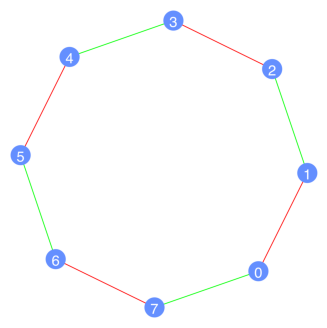

In [3]:
num_qubits = 8
ring_coupling, layers = create_coupling_and_layers(num_qubits)

plot_coupling_map(
    num_qubits=num_qubits,
    qubit_coordinates=None,
    coupling_map=ring_coupling,
    figsize=(4, 4),
    qubit_size=150,
    line_width=5,
    line_color=["red" if edge in layers[0] else "green" for edge in ring_coupling],
    font_size=90,
)

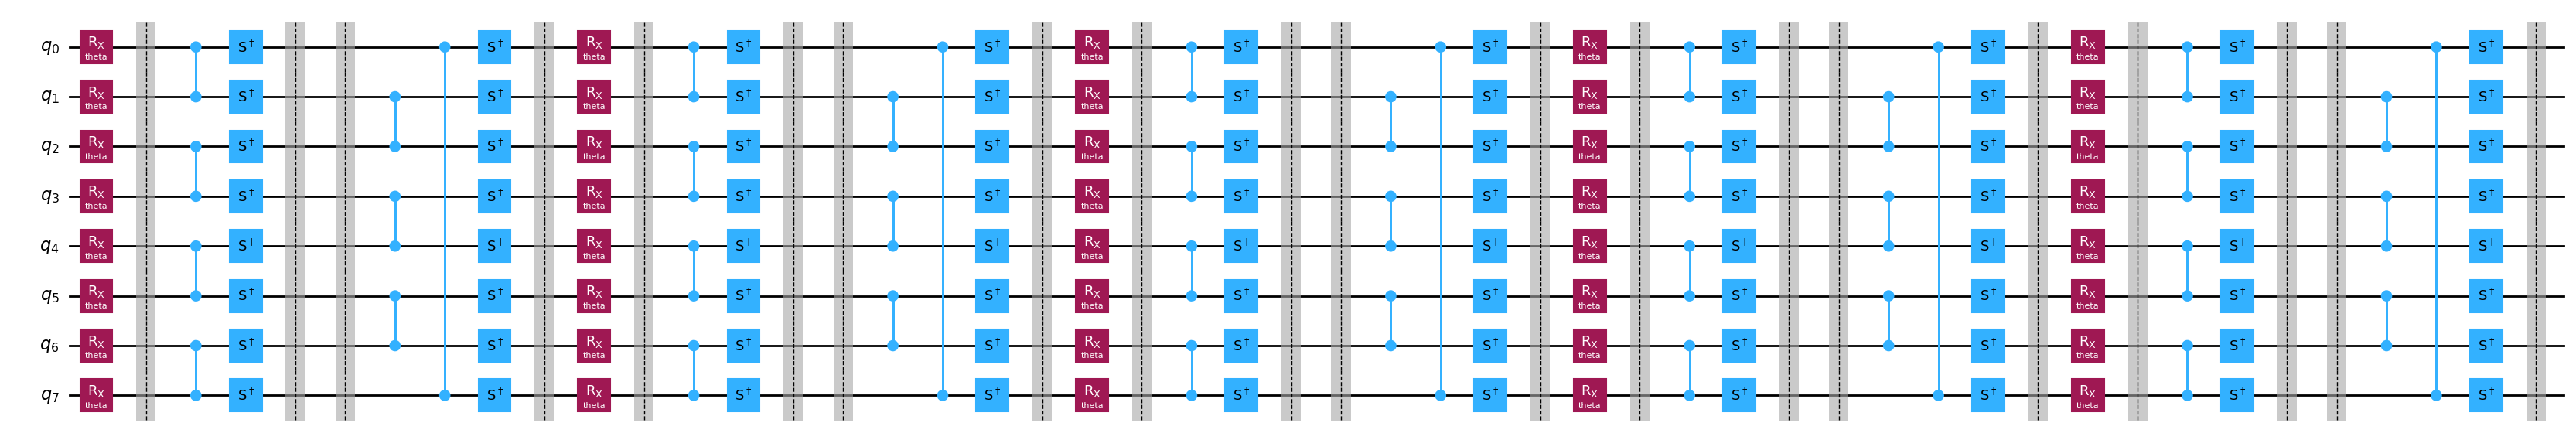

In [4]:
observables = [SparsePauliOp("I" * (num_qubits - q - 1) + "Z" + "I" * q) for q in range(num_qubits)]

# Parameter values: theta in [0, pi/2] - values for the transverse-field sweep
data_points = 6
parameter_values = np.linspace(0, np.pi / 2, data_points).reshape((data_points, 1))

theta = Parameter("theta")
trotter_steps = 5
circuit = trotter_circuit(theta, layers, trotter_steps)
circuit.draw("mpl", fold=100)

## Twirl only execution


As a baseline for comparison, we will compute the results of gate twirling mitigation and also the noiseless results.
We will use Pauli twirling (also known as [randomized compiling](https://journals.aps.org/pra/abstract/10.1103/PhysRevA.94.052325)), which has the effect of transforming any quantum channel into a Pauli channel. Pauli twirling can mitigate coherent noise because coherent noise tends to accumulate quadratically with the number of operations, whereas Pauli noise accumulates linearly.

First, we need to prepare a quantum program. Quantum program contains a quantum circuit and a samplex in a format suitable for the Executor primitive.
We can use the same quantum program to run both the noisy and noiseless simulations.
The default options are to twirl both the circuit gates and the measurements. In this guide we will not add any readout noise, therefore we can skip the measurement twirling by changing the boxing options - we set the "measure_annotations" boxing option to "change_basis" to indicate that the measurements should be modified only to measure at different bases (as opposed to "twirl" or "all" which will add measurement twirling).
In addition, we add "add_tags" to the boxing options, to allow the simulator map between the noise model and the boxes in the circuit to inject it to.

In [5]:
boxing_options = {
    "measure_annotations": "change_basis",
    "add_tags": "unique_box",
}
num_randomizations = 100
shots_per_randomization = 64

task_twirled = MitigationTask()
program = task_twirled.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
)

Executig the quantum program using the Executor in "local_mode" (simulator), and post processing the result to calculate the expectation values.

We start by executing the program using a noiseless simulator. We will later combine the different noisy tasks into the same program and execute them together. It is important for an execution in a real device, so the different task are executed in the same job.

In [6]:
noiseless_executor = AerExecutor(AerSimulator())

job_noiseless = noiseless_executor.run(program)
job_noiseless_results = job_noiseless.result()
noiseless_res = task_twirled.postprocess(job_noiseless_results)

## Create a noisy simulator
In this guide we will use a simulator that allows a `Samplex` as an input.
We will create a random noise model in the form of a `Pauli-Lindblad` channel for each uniqe layer of 2-qubit gates. This is an approximation of the twirled noise model.

In [7]:
def generate_random_pauli_lindblad_noise(
    layers,
    num_qubits: int,
    noise_scale: float = 1e-3,
    seed: int | None = None,
) -> dict[str, PauliLindbladMap]:
    """Generate random Pauli-Lindblad noise over the full Pauli basis."""
    noise_dict = {}
    for layer in layers:
        layer_instructions = layer.operation.params[0]
        contain_measurement = any(inst.name.startswith("measure") for inst in layer_instructions)
        layer_id = (
            get_annotation(layer.operation, Tag).ref
            if get_annotation(layer.operation, Tag)
            else None
        )
        if layer_id is None:
            continue
        if contain_measurement:  # do not add measurement noise
            layer_noise = PauliLindbladMap.identity(num_qubits)
        else:
            edges = [
                (inst.qubits[0]._index, inst.qubits[1]._index) for inst in layer_instructions
            ]  # extract the edges of the layer

            basis_paulis = [p for p in pauli_basis(2) if np.sum(p.x + p.z)]
            rng = np.random.default_rng(seed=seed)
            rates = rng.random(len(basis_paulis)) * noise_scale

            layer_noise = PauliLindbladMap.from_sparse_list(
                [
                    (pauli.to_label(), edge, rate)
                    for pauli, rate in zip(basis_paulis, rates, strict=True)
                    for edge in edges
                ],
                num_qubits=num_qubits,
            )
        noise_dict[layer_id] = layer_noise
    return noise_dict


backend = GenericBackendV2(
    num_qubits=num_qubits, basis_gates=["id", "rz", "sx", "x", "cz"], coupling_map=ring_coupling
)

# find the unique layers to generate the layered noise for
box_layers = find_combined_unique_layers([circuit], [task_twirled], boxing_options)

noise_map = generate_random_pauli_lindblad_noise(box_layers, num_qubits, seed=42)

# create a noisy simulator using the generated noise map
noisy_executor = AerExecutor(qasm_simulator=AerSimulator(), noise_dict=noise_map)

## ZNE mitigation
We will prepare a program that allow calculating mitigated expectation values using ZNE mitigation with digital gate folding. 
Mitigation using digital gate folding creates multiple items for execution - one for each noise amplification factor, as the circuit is modified and contains additional gates for amplification. We draw the twirled base circuit (with noise factor of 1) and the circuit with a noise factor of 3 to visualize the amplification.

We add the new items of the GateFolding task to the same program that contains the twirl only item, to execute them together.

In [9]:
task_gf = GateFolding()
program = task_gf.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
    quantum_program=program,
    folding_method="front",  # GateFolding option
    noise_factors=[1, 3, 5],  # GateFolding option
)

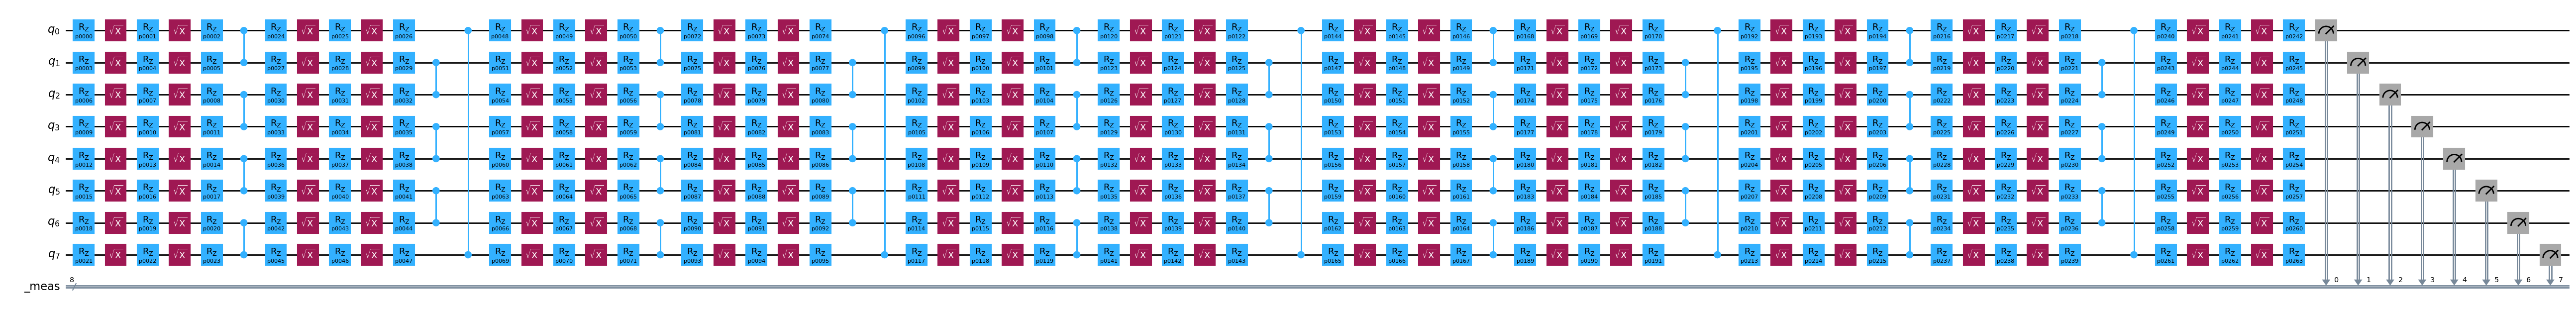

In [10]:
# visualise the circuit with noise factor of 1
program.items[1].circuit.draw("mpl", fold=100, plot_barriers=False)

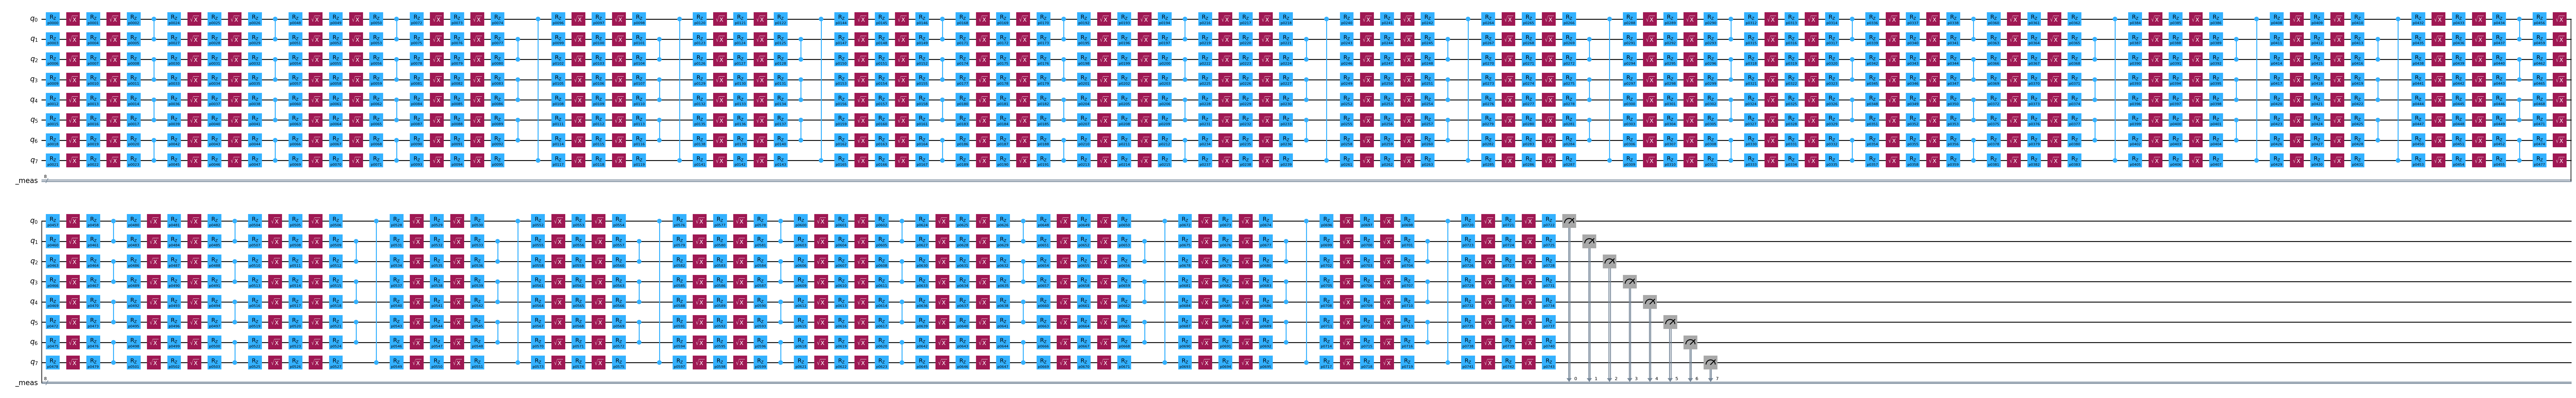

In [11]:
# visualise the circuit with noise factor of 3
program.items[2].circuit.draw("mpl", fold=125, plot_barriers=False)

In [12]:
job_noisy = noisy_executor.run(program)
job_noisy_results = job_noisy.result()

Important part of the ZNE methods is choosing an extrapolation method that approximates well the true noise trajectory. The extrapolation is done for each observable term. In this example, each observable contains a single term. The `postprocess` method can get a list of extrapolation methods. In that case, the methods will be run by order, choosing the first result with valid output within bounds.

In [13]:
twirl_res = task_twirled.postprocess(job_noisy_results)
gf_mitigated_res = task_gf.postprocess(job_noisy_results, extrapolator=["linear", "exponential"])

To visualize the extrapolation, we plot the calculated expectation values of each noise factor for the first observable for a parameter of $\theta = 0$, a linear fit and the extrapolated expectation value of the zero-noise point.

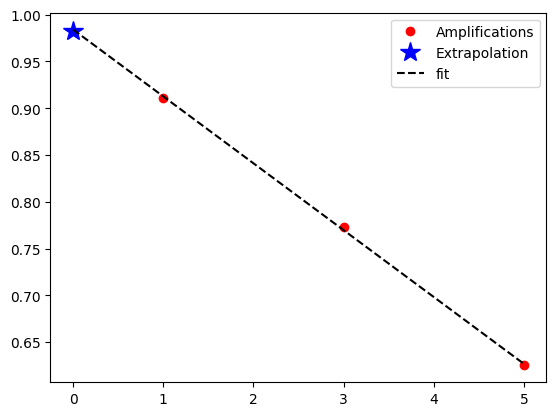

In [14]:
zero_noise = np.array([gf_mitigated_res.data.evs[0, 0]])
amplifications = gf_mitigated_res.data.evs_noise_factors[0, 0, :]
m, b = np.polyfit([1, 3, 5], amplifications, 1)
fit_values = m * np.array([0, 1, 3, 5]) + b

plt.plot([1, 3, 5], amplifications, "o", color="red", label="Amplifications")
plt.plot([0], zero_noise, "*", color="blue", markersize=15, label="Extrapolation")
plt.plot([0, 1, 3, 5], fit_values, "--", color="black", label="fit")
plt.legend()

### Custom extrapolation
Although "qiskit-mitigation" implements a variety of extrapolation types, a researcher might want to test a new extrapolation. It is possible to use a custom fitting function for the extrapolation. You need to supply as input to the post-processing method a tuple containing the fitting function, a list with an initial guess for each parameter of the fitting formula and bounds. These variables will be sent as arguments for ``scipy.optimize.curve_fit`` function, that will be used to fit the data to the formula in the supplied fitting function.
The post processing can be calculated using multiple times with different variables without the need to re-execute the program.

Here we show an example of using a custom square-root fitting function.

In [15]:
def sqrt_fit(x, a, b):
    return a * np.sqrt(x) + b


custom_fit = (sqrt_fit, [1.0, 1.0], (-np.inf, np.inf))

gf_mitigated_custom = task_gf.postprocess(
    job_noisy_results, extrapolator=["custom", "linear", "exponential"], custom_fit=custom_fit
)

## PEA Mitigation
PEA is a more sophisticated technique for amplifying the noise that performs preliminary experiments to reconstruct the noise and then uses this information to perform an accurate amplification. It starts by learning the twirled noise model of each layer of entangling gates in the circuit. After the learning phase, the circuits are executed at each noise factor, where every entangling layer of the circuit is amplified by probabilistically injecting noise proportional to the corresponding learned noise model. The more accurate the learned noise model will be, the more accurate the amplification will be.

### Learning the nosie for PEA
We assume a markovian noise model, therefore only the noise model of each unique layer of entangling gates should be learned, as the depth of the layer inside the circuit is assumed to not effect the noise channel of the layer.

We will use "qiskit-noise-learning" for learning the noise.

In [17]:
task_pea = PEA()
pea_layers = task_pea.find_unique_layers(circuit, boxing_options)

learning_options = LearningOptions(
    fragment_depths=[2, 4, 8, 16],
    num_randomizations=75,
    shots_per_randomizations=64,
)

learner = NoiseLearner(backend, options=learning_options, executor=noisy_executor)

noise_learn_job = learner.run(pea_layers[:-1])  # do not learn the noise of the measurement layer
noise_learn_result = noise_learn_job.result()
learned_noise_res = noise_learn_result.to_dict()
learned_noise = {
    get_annotation(layer.operation, InjectNoise).ref: learned_noise_res[noise_key]
    for layer, noise_key in zip(pea_layers[:-1], learned_noise_res.keys(), strict=True)
    if get_annotation(layer.operation, InjectNoise)
}

After the noise is learned, we can use it to prepare a `PEA` task.

In [18]:
program_pea = task_pea.prepare(
    circuit=circuit,
    observables=observables,
    parameters=parameter_values,
    num_randomizations=num_randomizations,
    shots_per_randomization=shots_per_randomization,
    custom_boxing_options=boxing_options,
    noise_maps=learned_noise,  # PEA option
    noise_factors=[1, 1.3, 1.5],  # PEA option
)

job_pea = noisy_executor.run(program_pea)
job_pea_results = job_pea.result()

pea_mitigated_res = task_pea.postprocess(job_pea_results, extrapolator=["linear", "exponential"])

## Plotting the results
Extrapolation based mitigation techniques have relative low execution overhead, but the bias of their result is not bounded. We can also see that choosing a good extrapolation method might be very important for the correctess of the results, as the custom fit of the square-root does not mitigate the noise well.

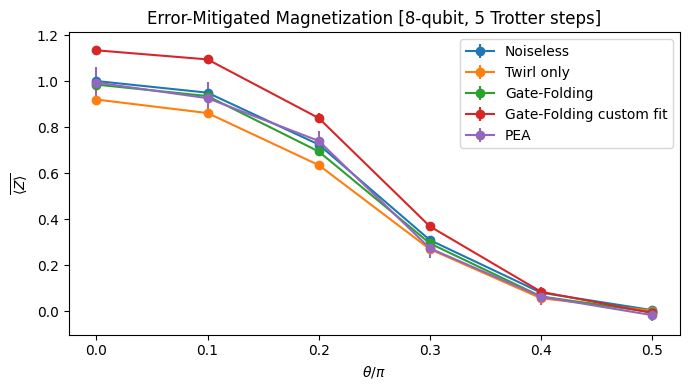

In [19]:
angles = parameter_values.ravel()
x_vals = angles / np.pi

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(
    x_vals,
    np.mean(noiseless_res.data.evs, axis=0),
    np.mean(noiseless_res.data.stds, axis=0),
    fmt="o-",
    label="Noiseless",
)
ax.errorbar(
    x_vals,
    np.mean(twirl_res.data.evs, axis=0),
    np.mean(twirl_res.data.stds, axis=0),
    fmt="o-",
    label="Twirl only",
)
ax.errorbar(
    x_vals,
    np.mean(gf_mitigated_res.data.evs, axis=0),
    np.mean(gf_mitigated_res.data.stds, axis=0),
    fmt="o-",
    label="Gate-Folding",
)
ax.errorbar(
    x_vals,
    np.mean(gf_mitigated_custom.data.evs, axis=0),
    np.mean(gf_mitigated_custom.data.stds, axis=0),
    fmt="o-",
    label="Gate-Folding custom fit",
)
ax.errorbar(
    x_vals,
    np.mean(pea_mitigated_res.data.evs, axis=0),
    np.mean(pea_mitigated_res.data.stds, axis=0),
    fmt="o-",
    label="PEA",
)

x_vals = np.linspace(x_vals.min(), x_vals.max(), trotter_steps)
ax.set_xlabel(r"$\theta/\pi$")
ax.set_ylabel(r"$\overline{\langle Z \rangle}$")
ax.legend()
ax.set_title(f"Error-Mitigated Magnetization [{num_qubits}-qubit, {trotter_steps} Trotter steps]")
plt.tight_layout()
plt.show()